In [2]:
# load ;ib

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

from pathlib import Path


sns.set_style("whitegrid")

print("lib loaded succesfully")

lib loaded succesfully


In [3]:
DATA = Path("../data/processed")

fund_master = pd.read_csv(DATA/"01_fund_master_cleaned.csv")
nav = pd.read_csv(DATA/"02_nav_history_cleaned.csv")
aum = pd.read_csv(DATA/"03_aum_by_fund_house_cleaned.csv")
sip = pd.read_csv(DATA/"04_monthly_sip_inflows_cleaned.csv")
category = pd.read_csv(DATA/"05_category_inflows_cleaned.csv")
folio = pd.read_csv(DATA/"06_industry_folio_count_cleaned.csv")
performance = pd.read_csv(DATA/"07_scheme_performance_cleaned.csv")
transactions = pd.read_csv(DATA/"08_investor_transactions_cleaned.csv")
holdings = pd.read_csv(DATA/"09_portfolio_holdings_cleaned.csv")
benchmark = pd.read_csv(DATA/"10_benchmark_indices_cleaned.csv")

print("Datasets Loaded Successfully")

Datasets Loaded Successfully


In [4]:
nav["date"] = pd.to_datetime(nav["date"])
aum["date"] = pd.to_datetime(aum["date"])
sip["month"] = pd.to_datetime(sip["month"])
category["month"] = pd.to_datetime(category["month"])
folio["month"] = pd.to_datetime(folio["month"])
transactions["transaction_date"] = pd.to_datetime(transactions["transaction_date"])
benchmark["date"] = pd.to_datetime(benchmark["date"])

In [5]:
import os

os.makedirs("../reports/charts", exist_ok=True)

# 1.Daily NAV Trend

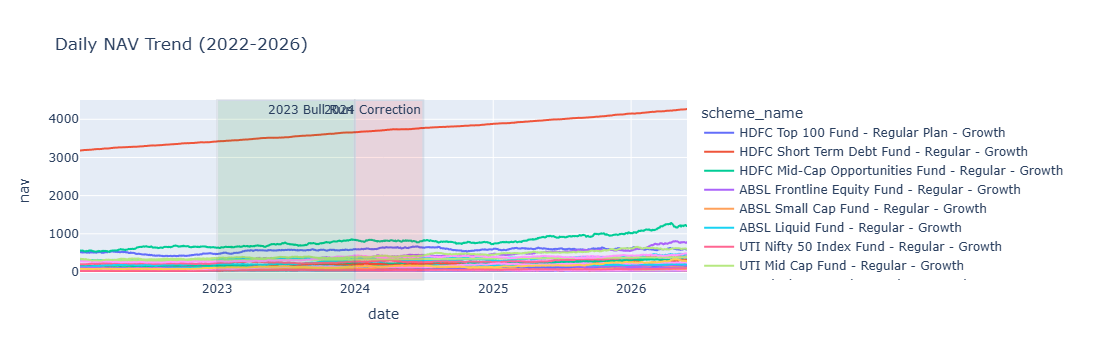

In [6]:
nav_plot = nav.merge(
    fund_master[["amfi_code","scheme_name"]],
    on="amfi_code"
)

fig = px.line(
    nav_plot,
    x="date",
    y="nav",
    color="scheme_name",
    title="Daily NAV Trend (2022-2026)"
)

fig.add_vrect(
    x0="2023-01-01",
    x1="2023-12-31",
    fillcolor="green",
    opacity=0.1,
    annotation_text="2023 Bull Run"
)

fig.add_vrect(
    x0="2024-01-01",
    x1="2024-06-30",
    fillcolor="red",
    opacity=0.1,
    annotation_text="2024 Correction"
)

fig.show()

fig.write_image("../reports/charts/nav_trend.png")

<b style="color:green">Most large-cap mutual funds showed a sustained increase in NAV during the 2023 bull market, while a noticeable correction occurred during the first half of 2024.<B>

# 2.AUM Growth by Fund House

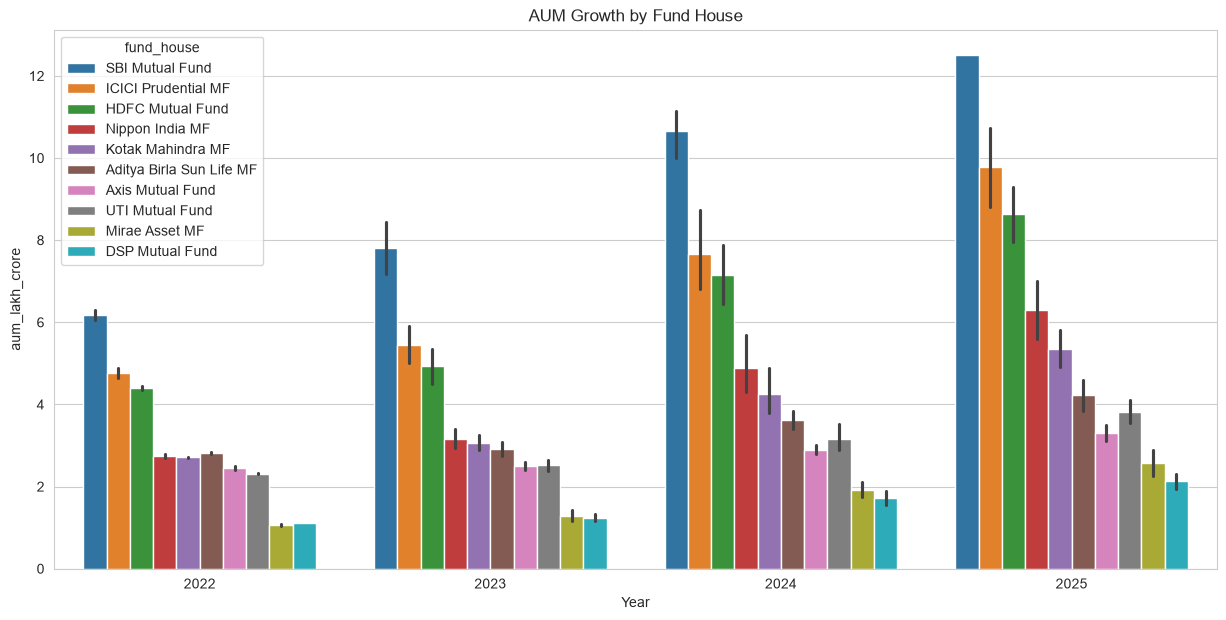

In [7]:
aum["Year"] = aum["date"].dt.year

plt.figure(figsize=(15,7))

sns.barplot(
    data=aum,
    x="Year",
    y="aum_lakh_crore",
    hue="fund_house"
)

plt.title("AUM Growth by Fund House")

plt.savefig("../reports/charts/aum_growth.png")

plt.show()

<b style="color:green">The Indian mutual fund industry has seen sustained AUM growth across all fund houses from 2022 to 2025, 
with SBI Mutual Fund maintaining a commanding lead followed by ICICI Prudential MF and HDFC MF. The growth accelerated between 2024 and 2025, and the gap between the top three players and the rest has widened, indicating increasing market concentration among the largest fund houses<b>

# 3. SIP Trend

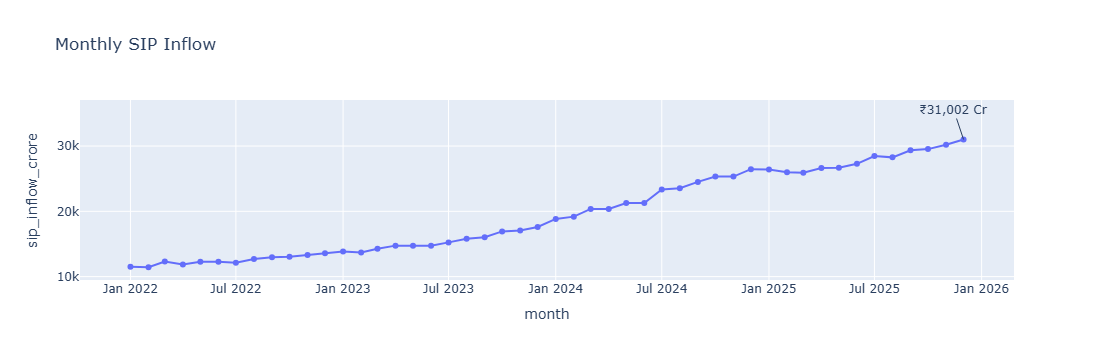

In [9]:
sip["month"] = pd.to_datetime(sip["month"])

sip["month"] = sip["month"].dt.to_pydatetime()

fig = px.line(
    sip,
    x="month",
    y="sip_inflow_crore",
    markers=True,
    title="Monthly SIP Inflow"
)

max_row = sip.loc[sip["sip_inflow_crore"].idxmax()]

fig.add_annotation(
    x=max_row["month"],
    y=max_row["sip_inflow_crore"],
    text="₹31,002 Cr"
)

fig.show()

fig.write_image("../reports/charts/sip_trend.png")

<b style ="color:green">Monthly SIP inflows reached an all-time high of ₹31,002 crore in December 2025, indicating strong retail investor participation.<b>

# 4.Category wise Net Inflows

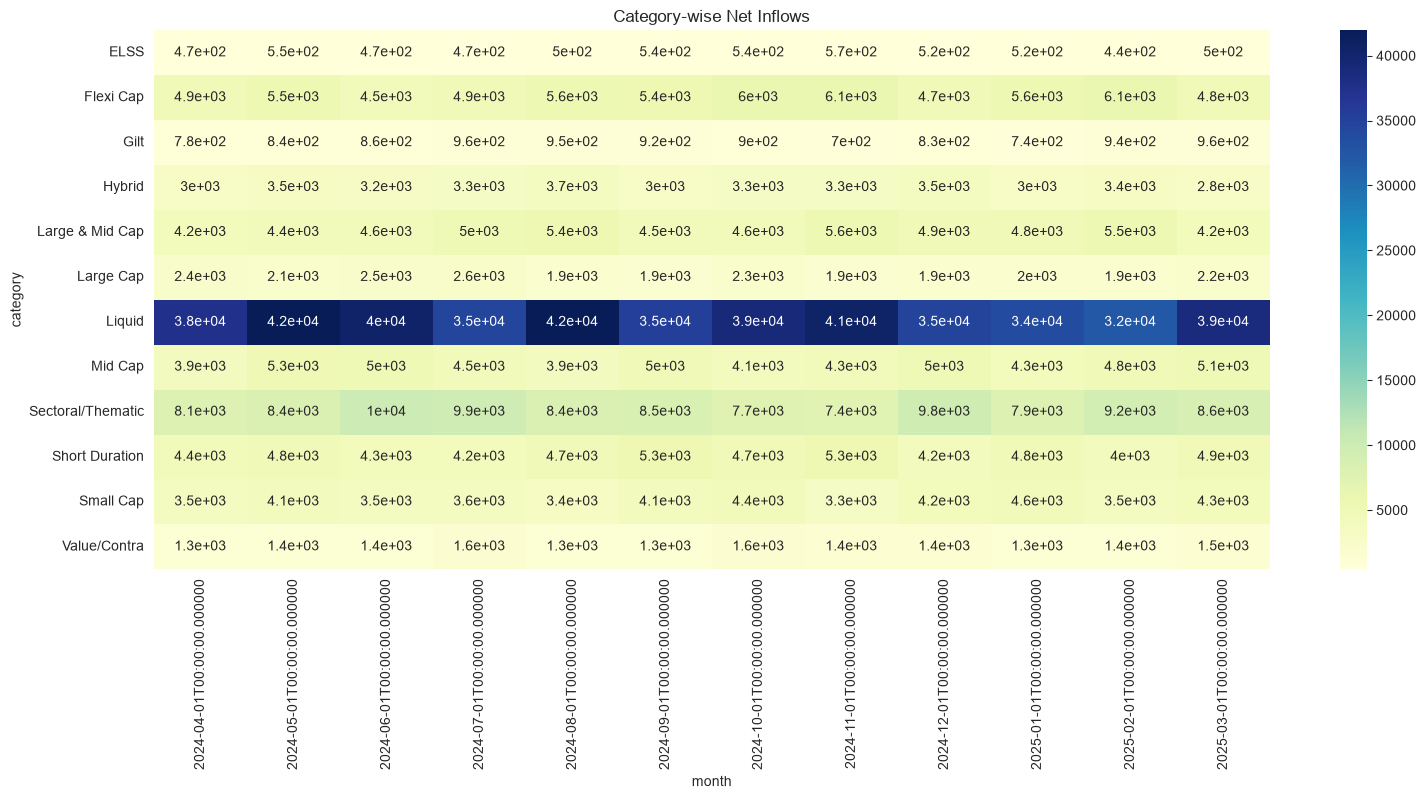

In [12]:
pivot = category.pivot_table(
    values="net_inflow_crore",
    index="category",
    columns="month"
)

plt.figure(figsize=(18,7))

sns.heatmap(
    pivot,
    cmap="YlGnBu",
    annot=True
    
)

plt.title("Category-wise Net Inflows")

plt.savefig("../reports/charts/category_heatmap.png")

plt.show()


<b style="color:green">The Liquid category consistently had the highest net inflows across the entire period, while categories like Gilt and Short Duration remained in negative territory (outflows) for most months.<b>

# 5. Age Distribution Pie

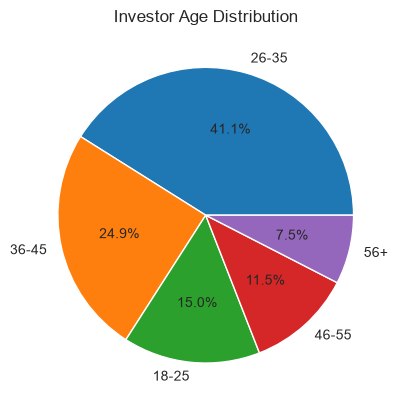

In [13]:
transactions["age_group"].value_counts().plot.pie(
    autopct="%1.1f%%"
)

plt.title("Investor Age Distribution")

plt.ylabel("")

plt.savefig("../reports/charts/age_distribution.png")

plt.show()

<b style="color:green">Nearly two-thirds (66%) of investors are under 36, with the 26–35 age group alone comprising the largest share at 41.1%. <b>

# 6. SIP Box Plot

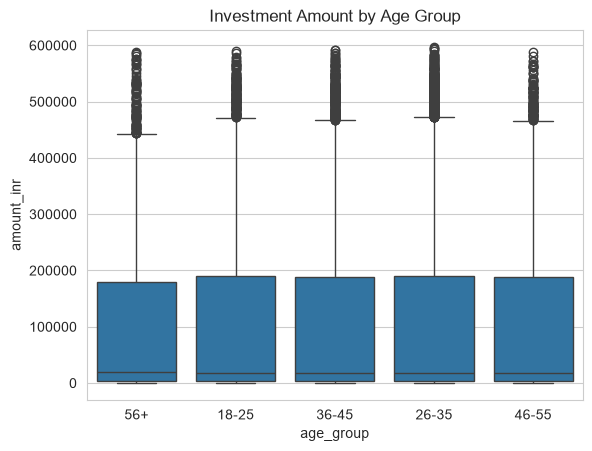

In [14]:
sns.boxplot(
    data=transactions,
    x="age_group",
    y="amount_inr"
)

plt.title("Investment Amount by Age Group")

plt.savefig("../reports/charts/boxplot_age.png")

plt.show()

<b>Across all age groups, the median investment amount is low (under ~50,000 INR) with a narrow interquartile range, but each group has numerous high-value outliers stretching up to 600,000 INR, indicating a small but consistent portion of investors across all ages invest significantly more than the typical investor. <b>

# 7. Gender Split

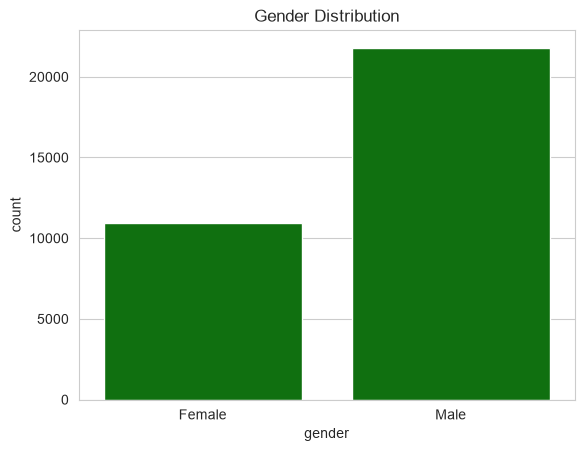

In [18]:
sns.countplot(
    data=transactions,
    x="gender",
    color = "green"
)

plt.title("Gender Distribution")

plt.savefig("../reports/charts/gender.png")

plt.show()

<b>Male investors outnumber female investors by roughly 2:1, with approximately 20,000 male investors compared to just over 10,000 female investors.<b>

# 8.State-wise Investment

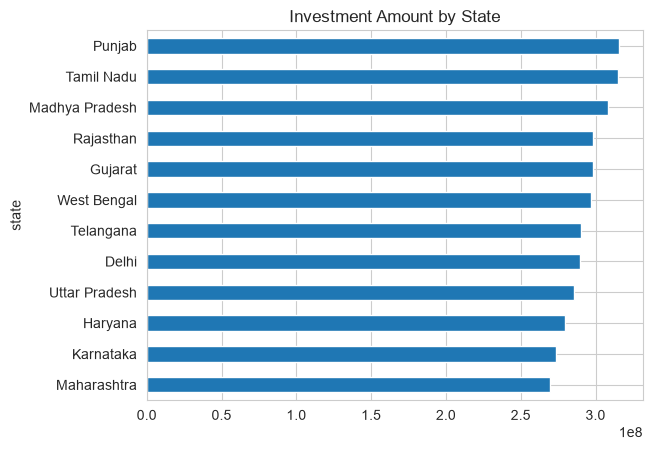

In [24]:
state = transactions.groupby("state")["amount_inr"].sum().sort_values()

state.plot.barh(
)

plt.title("Investment Amount by State")

plt.savefig("../reports/charts/state.png")

plt.show()

# 9. T30 vs B30

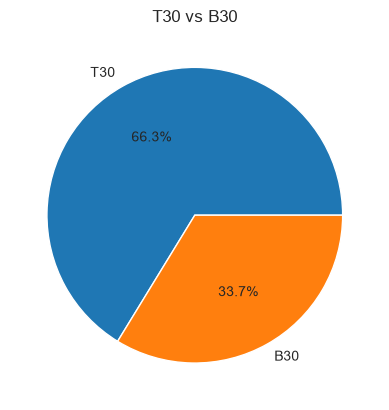

In [25]:
transactions["city_tier"].value_counts().plot.pie(
    autopct="%1.1f%%"
)

plt.ylabel("")

plt.title("T30 vs B30")

plt.savefig("../reports/charts/t30_b30.png")

plt.show()

<b style="color:green">About two-thirds (66.3%) of investors come from the top 30 cities (T30), while only one-third (33.7%) are from beyond the top 30 cities (B30), indicating a strong concentration of investors in major urban centers<b>

# 10.Industry Folio Growth Trend

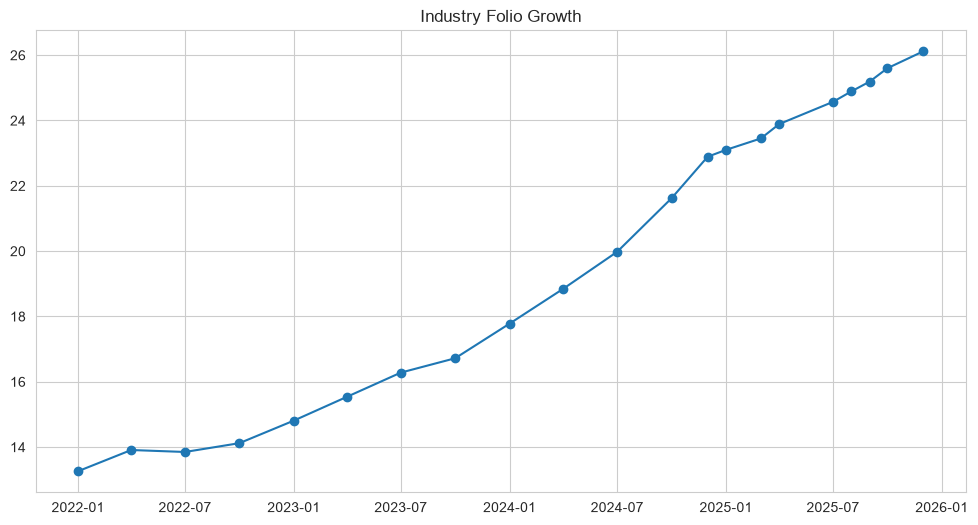

In [26]:
plt.figure(figsize=(12,6))

plt.plot(
    folio["month"],
    folio["total_folios_crore"],
    marker="o"
)

plt.title("Industry Folio Growth")

plt.savefig("../reports/charts/folio_growth.png")

plt.show()

<b style="color:green">Industry folio count nearly doubled from ~13.25 to 26 between January 2022 and January 2026, with growth accelerating notably from mid-2023 onwards.<b>

# 11. NAV Return Heatmap

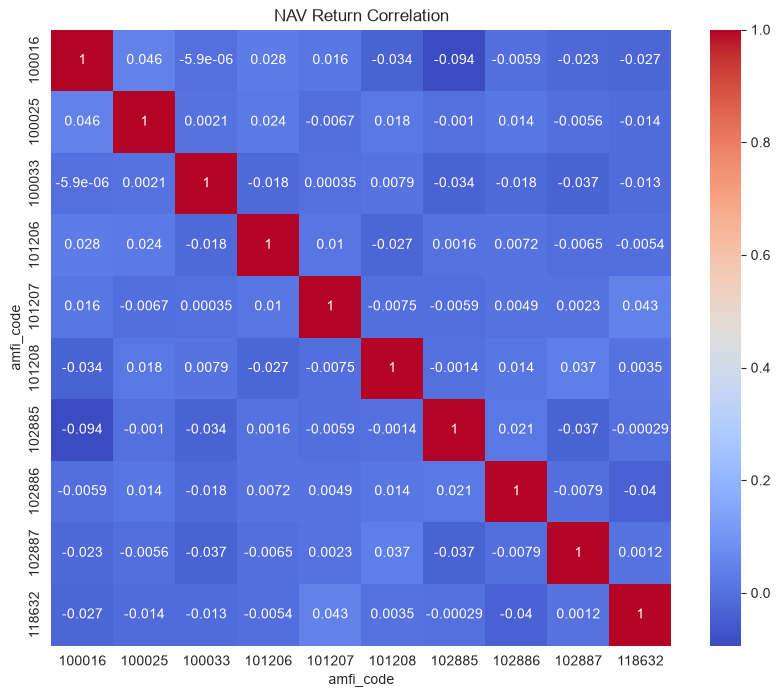

In [33]:
sample = nav["amfi_code"].unique()[:10]

corr = nav[
    nav["amfi_code"].isin(sample)
].pivot(
    index="date",
    columns="amfi_code",
    values="nav"
).pct_change().corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title("NAV Return Correlation")

plt.savefig("../reports/charts/correlation.png")

plt.show()

<b style="color:green">Most fund pairs show moderate to high positive correlations (red/orange), with the diagonal of perfect 1.0 self-correlation as expected, while a few funds exhibit near-zero or slightly negative correlations (blue/white), indicating limited diversification opportunities among the majority of these funds.<b>

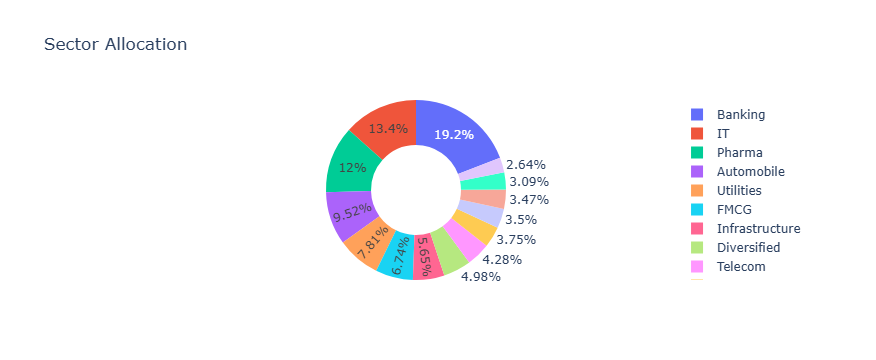

In [37]:
sector = holdings.groupby("sector")["weight_pct"].sum()

fig = px.pie(
    values=sector.values,
    names=sector.index,
    hole=0.5,
    title="Sector Allocation"
)

fig.show()

fig.write_image("../reports/charts/sector_donut.png")

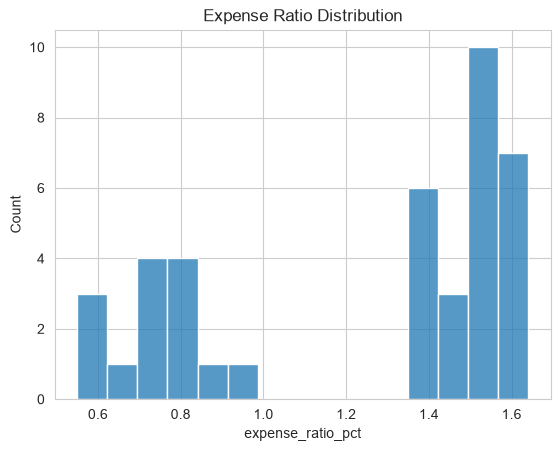

In [29]:
sns.histplot(performance["expense_ratio_pct"], bins=15)
plt.title("Expense Ratio Distribution")
plt.show()

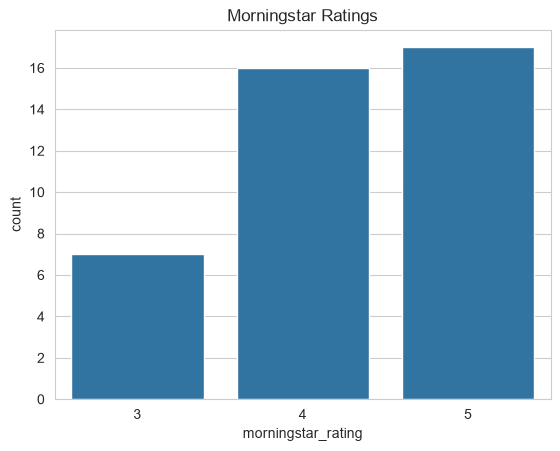

In [30]:
sns.countplot(
    x="morningstar_rating",
    data=performance
)

plt.title("Morningstar Ratings")

plt.show()

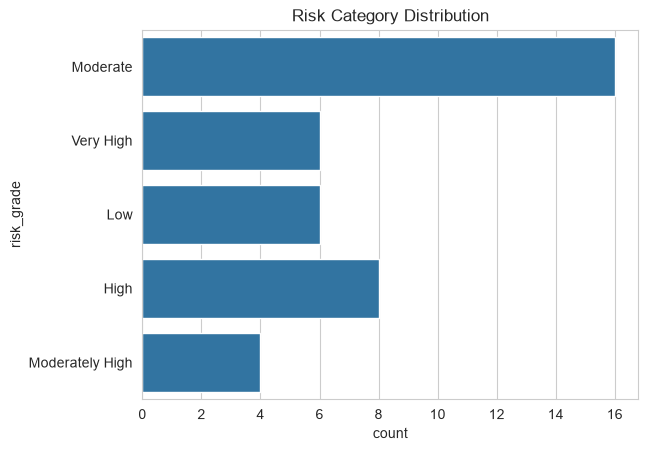

In [31]:
sns.countplot(
    y="risk_grade",
    data=performance
)

plt.title("Risk Category Distribution")

plt.show()